# HW1a Submission Details

### **Student**: Sagar Pratap Singh 

### **Student ID**: 1010736

### Weird Neural Networks

### About this notebook

This notebook is for use in the 61.502 Deep Learning course at the Singapore University of Technology and Design.

**Requirements:**
- Python 3 (tested on v3.9.6)
- Matplotlib (tested on v3.5.1)
- Numpy (tested on v1.22.1)
- Torch (tested on v1.13.0)
- Torchmetrics (tested on v0.11.0)

### Imports and CUDA

In [1]:
# Matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# Numpy
import numpy as np
# Torch
import torch
from torch.utils.data import TensorDataset, DataLoader
# Helper functions (additional file)
from helper_functions import *

In [2]:
# Use GPU if available, else use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


### Dataset generation

The dataset that will be used in this notebook looks very similar to what we have studied in class, with a few differences however...

Let us run the dataset generation, using our helper function **create_dataset()**, below.

In [3]:
# Parameters for helper functions
# - Minimum and maximum values
eps = 1e-5
min_val = -1 + eps
max_val = 1 - eps
# - Number of samples in training set
n_points_train = 10000
# - Number of samples in test set
n_points_test = 1000
# - Number of samples in validation set
n_points_valid = 1000
# - Batch size for training dataloader
batch_size = 512

**Question 1 [2 points]:** Based on the display for the dataset below, could you describe what seems to be the machine learning class we will be studying? More specifically,
- Is it a supervised or unsupervised task? Is it a regression or classification problem?
- What does the training dataset consist of, in terms of inputs and outputs? How many input and output features are present here?

**Answer**<br>

1(a) Based on the create_dataset() function and the plot, this is a supervised classification problem

1(b) The training dataset consists of - 
  - 2 inputs (val1,val2) which are the x,y coordinates in the plot. 
  - Output is 1 feature, which is a class label {0,1,2}



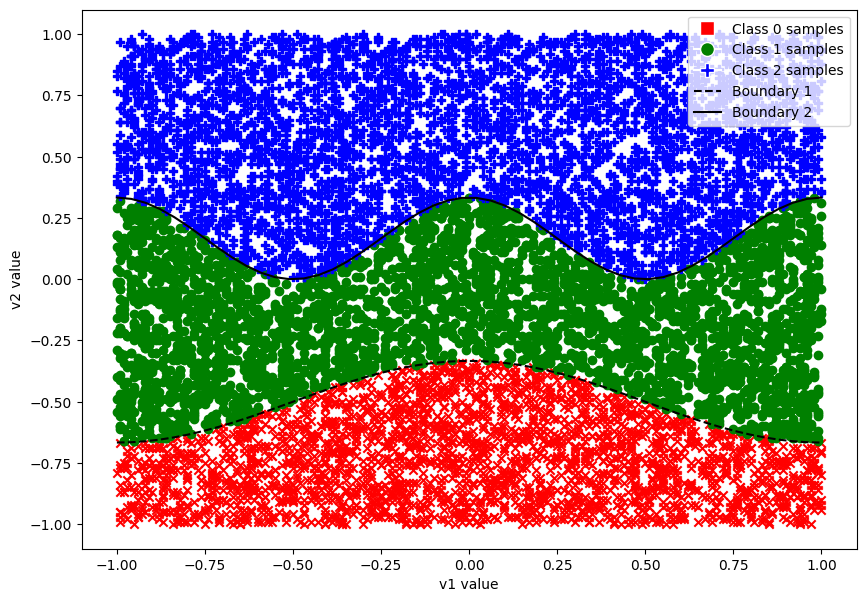

In [4]:
# Generate dataset (train)
np.random.seed(47)
train_val1_list, train_val2_list, train_inputs, train_outputs = create_dataset(n_points_train, min_val, max_val)
# Display training dataset
plot_dataset(min_val, max_val, train_val1_list, train_val2_list, train_outputs)

In [5]:
# Create train, test and validation dataloaders
train_loader, test_loader, valid_loader = generate_loaders(min_val, \
                                                           max_val, \
                                                           n_points_train, \
                                                           n_points_test, \
                                                           n_points_valid, \
                                                           batch_size, \
                                                           device)

### A Weird Activation Function

Let us consider the activation function, whose formula is given below

$$ f(x) = max \Big(0, \frac{2}{1 + exp(-x)} - 1 \Big) $$

**Question 2 [2 points]:** How would you write the function $ f $ using Numpy? Show the code for the **weird_function_np()** function in your report.

In [6]:
def weird_function_np(x):
    v = (2 / (1 + np.exp(-x))) - 1
    f = np.maximum(0, v)
    return f

**Question 3 [2 points]:** Based on the matplotlib display for the given function below, do you think we could use this function as an activation function for a Neural Network? If you had to describe this function, using examples of activation functions we have seen in class, how would you describe it?

**Answer**<br>

Based on the plot, here are the observations of this activation function-
- For x < 0: outputs 0, like ReLU
- For x > 0: smoothly rises but caps at 1, like sigmoid

Yes, this function can be used as an activation function for a Neural Network. It is non-linear, differentiable, and has a bounded output range [0, 1].

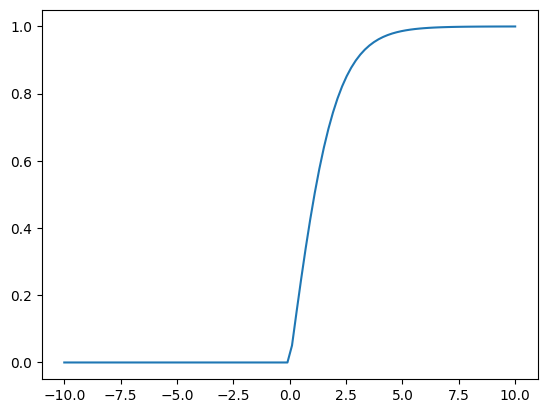

In [7]:
plt.plot(np.linspace(-10, 10, 100), [weird_function_np(x) for x in np.linspace(-10, 10, 100)])
plt.show()

### A Weird building block, using our weird activation function

**Question 4 [6 points]:** The building block below should consist of a Linear layer with inputs dimension $ n_x $ and output dimension $ n_y $ followed by our weird activation function, that will be implemented in the **weird_function_torch()** method this time. How would you fill the blanks for **self.fc**, **val** and **out** in the code below? Show and explain the code briefly in your report.

In [10]:
class WeirdBlock(torch.nn.Module):
    def __init__(self, n_x = 2, n_y = 1):
        super().__init__()
        # Define Linear layer using the nn.Linear()
        self.fc = torch.nn.Linear(n_x, n_y)

    def weird_function_torch(self, x):
        val = torch.clamp((2/(1+torch.exp(-x))-1), min=0)
        return val

    def forward(self, x):
        # Our Weird operation
        z = self.fc(x)
        out = self.weird_function_torch(z)
        return out

**Code Explanation**

- We define the fully connected (fc) linear layer in the initiation (init) method of WeirdBlock that accepts input (dim n_x) and output (dim n_y). All linear layers with learnable parameters are defined in __init__()
- We also implemented the activation function to be applied to the linear layer output, this time as a Pytorch operation so that Pytorch can track the gradients during backpropagation. 
- In forward() pass we connect these blocks -> linear layer followed by activation function and return the output 

### Building a Deep Neural Network

Let us now define our Deep Neural Network

For any given non-empty list of sizes in $ n_h $, we would like to use our WeirdBlock object from earlier.
- The first layer, will consist of a WeirdBlock with input size $ n_x $ and output size $ n_h[0] $,
- Every consecutive layer will consist of a WeirdBlock with input size $ n_h[i] $ and output size $ n_h[i+1] $ (until the list $ n_h $ runs out of elements
- Eventually, the last layer will consist of a simple Linear layer, with input size $ n_h[-1] $ and output size $ n_y $.

**Question 5 [6 points]:** How would you modify the code below? More specifically,
- How would you fill the blanks to define the **self.processing_layers** attribute?
- How would you write the Sequential combination of layers in the **self.combined_layers** attribute?

Show the code in your report and explain it briefly.

In [11]:
class DeepNeuralNet(torch.nn.Module):
    def __init__(self, n_x = 2, n_h = [10], n_y = 3):
        super().__init__()
        # Define the correct number of layers based on n_h,
        # Use the correct number of WeirdBlock layers,
        # And finish with a single Linear layer
        values = [n_x] + n_h
        self.processing_layers = [WeirdBlock(values[i], values[i+1]) for i in range(len(values)-1)]
        self.processing_layers += [torch.nn.Linear(values[-1], n_y)]

        # Combine all layersc
        self.combined_layers = torch.nn.Sequential(*self.processing_layers)

    def forward(self, x):
        # Pass through all four layers
        out = self.combined_layers(x)
        return out

**Code Explanation**

- We concatenated n_x with [n_h] to create a list of layer dimensions (values) that we can iterate through to create the correct number of WeirdBlock layers
- Finally we added a Linear layer that uses the last hidden layer dimension as input and n_y as output
- We then combined all the layers into a single sequential block that we can pass the input through in the forward() method 

If you have correctly figured out the code above, the cell below should produce an output, which looks like:

```
<bound method Module.modules of DeepNeuralNet(
  (combined_layers): Sequential(
    (0): WeirdBlock(
      (fc): Linear(in_features=2, out_features=10, bias=True)
    )
    (1): WeirdBlock(
      (fc): Linear(in_features=10, out_features=5, bias=True)
    )
    (2): Linear(in_features=5, out_features=3, bias=True)
  )
)>
```

In [12]:
# Initialize the model
torch.manual_seed(43)
model = DeepNeuralNet(n_x = 2, n_h = [10, 5], n_y = 3).to(device)
# This will display a recap of the different layers
print(model.modules)

<bound method Module.modules of DeepNeuralNet(
  (combined_layers): Sequential(
    (0): WeirdBlock(
      (fc): Linear(in_features=2, out_features=10, bias=True)
    )
    (1): WeirdBlock(
      (fc): Linear(in_features=10, out_features=5, bias=True)
    )
    (2): Linear(in_features=5, out_features=3, bias=True)
  )
)>


**Question 6 [6 points]:** How would you fill the blanks to make predictions with your (currently untrained) model?
More specifically,
- How would you fill the blank for the **outputs** variable, so that it contains the logits values produced by the model?
- How would you fill the blank so that the **predicted** variable now consists of a tensor with a similar number of lines as the **inputs** one, but only one column, with values being integers between $ \{0, 1, 2\} $, corresponding to the prediction formulated by the Neural Network?

In [13]:
def predict(model, inputs, device):
    outputs = model(inputs)
    _, predicted = torch.max(outputs, 1)
    return outputs, predicted

If the **predict()** function has been correctly implemented, it should return
- the following values for **outputs.data**:
```
[[-0.0924,  0.3132,  0.4449],
[-0.0867,  0.3166,  0.4524],
[-0.0800,  0.3242,  0.4656],
[-0.0663,  0.3089,  0.4701],
[-0.0792,  0.3162,  0.4603],
[-0.0759,  0.3119,  0.4612],
[-0.0741,  0.3081,  0.4613],
[-0.0770,  0.3078,  0.4581],
[-0.0938,  0.3128,  0.4425],
[-0.0872,  0.3077,  0.4472]]
```
- the following values for **predicted.data**:
```
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
```

In [17]:
# Initialize the model
torch.manual_seed(43)
model = DeepNeuralNet(n_x = 2, n_h = [10, 5], n_y = 3).to(device)
for batch in train_loader:
    inputs, outputs = batch
    outputs, predicted = predict(model, inputs[0:10, :], device)
    print(outputs.data)
    print(predicted.data)
    break

tensor([[-0.0924,  0.3132,  0.4449],
        [-0.0867,  0.3166,  0.4524],
        [-0.0800,  0.3242,  0.4656],
        [-0.0663,  0.3089,  0.4701],
        [-0.0792,  0.3162,  0.4603],
        [-0.0759,  0.3119,  0.4612],
        [-0.0741,  0.3081,  0.4613],
        [-0.0770,  0.3078,  0.4581],
        [-0.0938,  0.3128,  0.4425],
        [-0.0872,  0.3077,  0.4472]])
tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])


**Question 7 [5 points]:** We would like to modify the define_optimizer() function below, so that the optimizer being used is the RMSProp one, with parameters 1 for the learning rate and .99 for the alpha coefficient, used in the squared gradients update formula.




In [18]:
def define_optimizer(model, lr, alpha):
    # Define optimizer
    optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, alpha=alpha)
    optimizer.zero_grad()
    return optimizer

If you have correctly implemented the code above, the cell below should display
```
RMSprop (
Parameter Group 0
    alpha: .99
    centered: False
    eps: 1e-08
    foreach: None
    lr: 1
    momentum: 0
    weight_decay: 0
)
```

In [20]:
optimizer = define_optimizer(model, lr = 1, alpha = .99)
print(optimizer)

RMSprop (
Parameter Group 0
    alpha: 0.99
    capturable: False
    centered: False
    differentiable: False
    eps: 1e-08
    foreach: None
    lr: 1
    maximize: False
    momentum: 0
    weight_decay: 0
)


### Training the Deep Neural Network

**Question 8 [6 points]:** Answer the questions below.
- What should be the loss function to use in the **loss** variable of the **trainer()** function below?
- Does it require that we use the **softmax** function on the **outputs** variable before passing it to the loss function? - Or can we simply pass the outputs as such (even if these values do not sum up to 1) and let the loss function figure it out?

**Answer**

- Since this is a multi-class classification problem, we should use Cross Entropy loss function so that it can (a) work with probabilities and (b) penalize wrong confidence
- In Pytorch, the built-in cross entropy loss function already computes softmax internally on the raw logits. Computing log(softmax(x)) for cross entropy loss directly is numerically more stable than computing softmax first and then log separately

In [22]:
def trainer(model, train_loader, test_loader, valid_loader, num_epochs = 10, lr = 0.1, alpha = 0.99):

    # History for train acc, test acc
    train_accs = []
    valid_accs = []

    # Define optimizer
    optimizer = define_optimizer(model, lr, alpha)

    # Training model
    for epoch in range(num_epochs):
        # Go trough all samples in train dataset
        model.train()
        correct = 0
        total = 0
        for i, (inputs, labels) in enumerate(train_loader):
            # Get from dataloader and send to device
            inputs = inputs.to(device)
            labels = labels.reshape(-1).to(device)

            # Forward pass
            outputs, predicted = predict(model, inputs, device)

            # Check if predicted class matches label and count numbler of correct predictions
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Compute loss
            loss = torch.nn.CrossEntropyLoss()(outputs, labels)

            # Backward and optimize
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Display losses over iterations and evaluate on validation set
            if (i+1) % 10 == 0:
                train_accuracy, valid_accuracy = display_train(epoch, num_epochs, i, model, \
                                                               correct, total, loss, \
                                                               train_loader, valid_loader, device)

        # Append accuracies to list at the end of each iteration
        train_accs.append(train_accuracy)
        valid_accs.append(valid_accuracy)

    # Evaluate on test after training has completed
    test_acc = eval_test(model, test_loader, device)

    # Return
    return train_accs, valid_accs, test_acc

After you have completed the blanks in all questions, you should be able to run the two cells below.

In [138]:
torch.manual_seed(43)
model = DeepNeuralNet(n_x = 2, n_h = [20, 10], n_y = 3).to(device)
train_accs, valid_accs, test_acc = trainer(model, train_loader, test_loader, valid_loader, \
                                           num_epochs = 50, lr = 1, alpha = 0.99)

Epoch [1/50], Step [10/20], Train Loss: nan
Epoch [1/50], Train Accuracy: 0.2938
Epoch [1/50], Validation Accuracy: 0.2580
Epoch [1/50], Step [20/20], Train Loss: nan
Epoch [1/50], Train Accuracy: 0.2735
Epoch [1/50], Validation Accuracy: 0.2580
Epoch [2/50], Step [10/20], Train Loss: nan
Epoch [2/50], Train Accuracy: 0.2533
Epoch [2/50], Validation Accuracy: 0.2580
Epoch [2/50], Step [20/20], Train Loss: nan
Epoch [2/50], Train Accuracy: 0.2544
Epoch [2/50], Validation Accuracy: 0.2580
Epoch [3/50], Step [10/20], Train Loss: nan
Epoch [3/50], Train Accuracy: 0.2566
Epoch [3/50], Validation Accuracy: 0.2580
Epoch [3/50], Step [20/20], Train Loss: nan
Epoch [3/50], Train Accuracy: 0.2544
Epoch [3/50], Validation Accuracy: 0.2580
Epoch [4/50], Step [10/20], Train Loss: nan
Epoch [4/50], Train Accuracy: 0.2508
Epoch [4/50], Validation Accuracy: 0.2580
Epoch [4/50], Step [20/20], Train Loss: nan
Epoch [4/50], Train Accuracy: 0.2544
Epoch [4/50], Validation Accuracy: 0.2580
Epoch [5/50], St

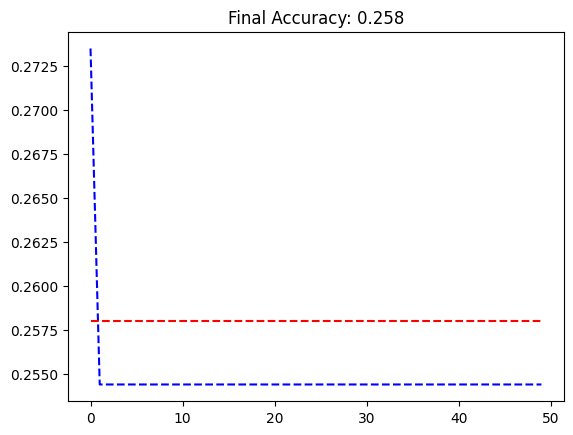

In [139]:
plt.plot(train_accs, "b--")
plt.plot(valid_accs, "r--")
plt.title("Final Accuracy: {}".format(test_acc))
plt.show()

**Question 9 a.[10 points]**  When running the above model, it seems the model is not capable of achieving a great accuracy. If anything, it seems to remain stuck at an accuracy of less than 30% or so.The losses seems to be very large number. Did we make a mistake in one of our hyperparameters (e.g. the learning rate)? Or is the model simply incapable of figuring out this task (maybe because of the weird activation function we have decided to use)? Explain your understanding of the reasons for this weird behaviour?

**Answer**

*Root cause*: The learning rate (lr=1) is too high, and the bounded weird activation function prevents the model from recovering once weights are pushed to extreme values.        

*Step by step:*
  1. With lr=1, weight updates are excessively large, causing weights to grow to extreme values after just a few iterations
  2. The linear layer computes z = weight × input + bias. Even though inputs are small (range [-1, 1]), the large weights amplify them into extreme values, pushing neurons into one of the weird activation's two flat regions:
    - For x < 0: the max(0, ...) clips output to 0, gradient is exactly 0
    - For large x > 0: the sigmoid saturates toward 1, gradient formula 2 * sigmoid(x) * (1 - sigmoid(x)) collapses to near 0
  3. With gradients near zero, weight_update = lr × gradient ≈ 0 — the weights cannot change. The model is stuck because the very mechanism it needs to fix itself (gradients) has been destroyed
  4. Meanwhile, the extreme logit values cause numerical overflow — exp(-x) produces inf, which propagates into the Cross Entropy loss as nan. Once nan enters the computation, all subsequent calculations break

*Summary:* The high learning rate pushes weights to extremes where the weird activation's gradients vanish, trapping the model permanently. A standard unbounded activation like ReLU would not suffer the same issue since its gradient stays 1 for all positive inputs. The fix is to reduce the learning rate so that weights remain in the activation's active zone where gradients are healthy.

**Question 9 b. [15 points]:** Assuming you figured out what was wrong in Question 9, show in your report how you resolved the problem in the code above.
Your model should be able to produce a final training accuracy above 98%.

**Answer**

By reducing the learning rate from 1 to 0.01:
  With lr=0.01, weight updates are small enough to keep values in a numerically stable range. The model successfully learns the decision boundaries, achieving:
  - Training accuracy: 98.45%
  - Validation accuracy: 98.80%
  - Test accuracy: 98.70%

*Code and Results shown below*

In [140]:
torch.manual_seed(43)
model = DeepNeuralNet(n_x = 2, n_h = [20, 10], n_y = 3).to(device)
train_accs, valid_accs, test_acc = trainer(model, train_loader, test_loader, valid_loader, \
                                           num_epochs = 50, lr = 0.01, alpha = 0.99)

Epoch [1/50], Step [10/20], Train Loss: 0.6136
Epoch [1/50], Train Accuracy: 0.5605
Epoch [1/50], Validation Accuracy: 0.6620
Epoch [1/50], Step [20/20], Train Loss: 0.4885
Epoch [1/50], Train Accuracy: 0.6769
Epoch [1/50], Validation Accuracy: 0.8250
Epoch [2/50], Step [10/20], Train Loss: 0.3696
Epoch [2/50], Train Accuracy: 0.9047
Epoch [2/50], Validation Accuracy: 0.9030
Epoch [2/50], Step [20/20], Train Loss: 0.2685
Epoch [2/50], Train Accuracy: 0.9124
Epoch [2/50], Validation Accuracy: 0.9060
Epoch [3/50], Step [10/20], Train Loss: 0.2779
Epoch [3/50], Train Accuracy: 0.9281
Epoch [3/50], Validation Accuracy: 0.9100
Epoch [3/50], Step [20/20], Train Loss: 0.2249
Epoch [3/50], Train Accuracy: 0.9279
Epoch [3/50], Validation Accuracy: 0.9240
Epoch [4/50], Step [10/20], Train Loss: 0.2084
Epoch [4/50], Train Accuracy: 0.9225
Epoch [4/50], Validation Accuracy: 0.9200
Epoch [4/50], Step [20/20], Train Loss: 0.1976
Epoch [4/50], Train Accuracy: 0.9309
Epoch [4/50], Validation Accuracy:

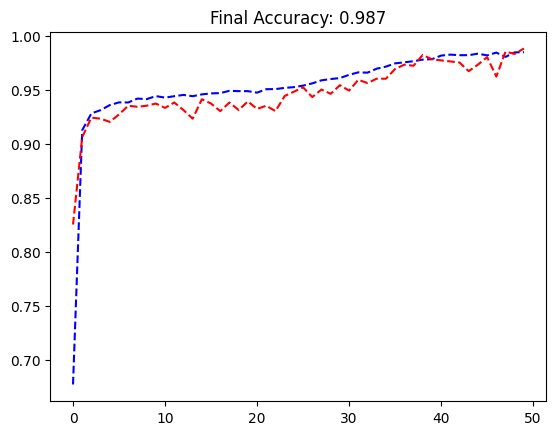

In [141]:
plt.plot(train_accs, "b--")
plt.plot(valid_accs, "r--")
plt.title("Final Accuracy: {}".format(test_acc))
plt.show()

### Up for a challenge? Bonus Question

**Question 10 [10 points]:** Could you suggest things to do to improve this score further and possibly bring it towards 100%?

Showing code of a Neural Network that achieves a 99.5+% accuracy on the test set would be nice.

**Answer**

To push accuracy beyond 99.5%, three changes were made:

  1. Deeper and wider network — changed hidden layers from [20, 10] to [80, 40, 20]. The original 2-layer network lacked capacity to precisely model the non-linear cosine decision boundaries. Adding a third hidden layer with more neurons allows the model to learn finer distinctions between classes.
  2. Lower learning rate — changed from 0.01 to 0.005. A smaller learning rate enables finer weight adjustments in later epochs, helping the model converge more precisely.
  3. More training epochs — increased from 50 to 250. The smaller learning rate requires more iterations to fully converge.

*Hyperparameter updates:*

<small>
  torch.manual_seed(43)<br>
  model = DeepNeuralNet(n_x=2, n_h=[80, 40, 20], n_y=3).to(device)<br>
  train_accs, valid_accs, test_acc = trainer(model, train_loader, test_loader, valid_loader,<br>
                                            num_epochs=250, lr=0.005, alpha=0.99)
</small>


This achieves a test accuracy of **99.8%**

Further possible improvements:
  - Early stopping — monitor validation accuracy and save the best model, rather than using a fixed number of epochs
  - Learning rate scheduling — start with a higher learning rate for fast initial convergence and decay it over time for fine-tuning
  - Adam optimizer — combines momentum with adaptive learning rates, often converging faster and more stably than RMSProp

*Code & Results shown below*

In [136]:
torch.manual_seed(43)
model_v2 = DeepNeuralNet(n_x = 2, n_h = [80, 40, 20], n_y = 3).to(device)
train_accs, valid_accs, test_acc = trainer(model_v2, train_loader, test_loader, valid_loader, \
                                           num_epochs = 250, lr = 0.005, alpha = 0.99)

Epoch [1/250], Step [10/20], Train Loss: 0.5599
Epoch [1/250], Train Accuracy: 0.6264
Epoch [1/250], Validation Accuracy: 0.7900
Epoch [1/250], Step [20/20], Train Loss: 0.4343
Epoch [1/250], Train Accuracy: 0.7344
Epoch [1/250], Validation Accuracy: 0.8480
Epoch [2/250], Step [10/20], Train Loss: 0.2732
Epoch [2/250], Train Accuracy: 0.9105
Epoch [2/250], Validation Accuracy: 0.9330
Epoch [2/250], Step [20/20], Train Loss: 0.2447
Epoch [2/250], Train Accuracy: 0.9226
Epoch [2/250], Validation Accuracy: 0.9150
Epoch [3/250], Step [10/20], Train Loss: 0.1629
Epoch [3/250], Train Accuracy: 0.9357
Epoch [3/250], Validation Accuracy: 0.9340
Epoch [3/250], Step [20/20], Train Loss: 0.1466
Epoch [3/250], Train Accuracy: 0.9362
Epoch [3/250], Validation Accuracy: 0.9210
Epoch [4/250], Step [10/20], Train Loss: 0.2060
Epoch [4/250], Train Accuracy: 0.9453
Epoch [4/250], Validation Accuracy: 0.9410
Epoch [4/250], Step [20/20], Train Loss: 0.1082
Epoch [4/250], Train Accuracy: 0.9481
Epoch [4/25

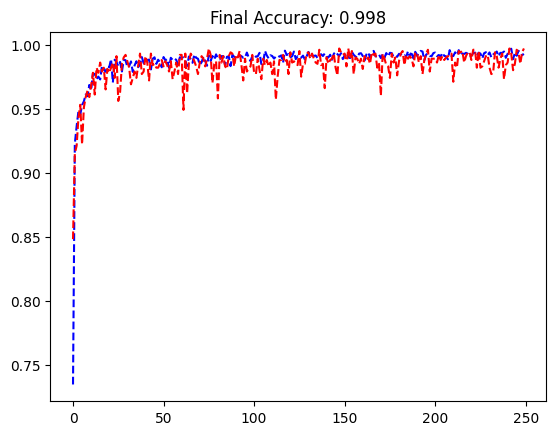

In [137]:
plt.plot(train_accs, "b--")
plt.plot(valid_accs, "r--")
plt.title("Final Accuracy: {}".format(test_acc))
plt.show()